In [1]:
import sys
import os

print("Current Working Directory:", os.getcwd())

Current Working Directory: /Users/anjansuputra/Documents/GitHub/Emasters_Group-2_CapstoneProject


In [2]:
from pathlib import Path
import json
import re
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

project_root = Path.cwd()
sys.path.append(str(project_root))
sys.path.append(str(project_root / "src"))

from config import load_config
from src.data.data_loader import DatasetLoader
from src.models.load_model import ModelLoader
from src.generators.program_generator import GenerationPipeline
from src.generators.text_to_mongo_generator import TextToMongoGenerator
from src.evaluation.metrics import EvaluationMetrics
from src.evaluation.visualization import ResultVisualizer

print("✅ Imports ready.")

✅ Imports ready.


In [3]:
config = load_config("configs/config.yaml")

bertscore_model_resolved = config.evaluation.resolve_bertscore_model(base_dir="models/codebert-base")

print(f"Base Model      : {config.model_name}")
print(f"Device          : {config.evaluation.device}")
print(f"LoRA Output Dir : {config.lora.output_dir}")
if bertscore_model_resolved == config.evaluation.bertscore_model:
    print(f"BERTScore Model : {bertscore_model_resolved}  (⚠️ local checkpoint not found at "
          f"'{config.evaluation.bertscore_local_path}' -- will download from Hugging Face Hub)")
else:
    print(f"BERTScore Model : {bertscore_model_resolved}  (✅ loaded from local checkpoint)")

Base Model      : Qwen/Qwen2.5-Coder-0.5B-Instruct
Device          : cpu
LoRA Output Dir : models/checkpoints/lora_finetuned
BERTScore Model : /Users/anjansuputra/Documents/GitHub/Emasters_Group-2_CapstoneProject/models/codebert-base  (✅ loaded from local checkpoint)


In [4]:
N_EVAL_SAMPLES = 100  

data_loader = DatasetLoader(target_filename="qwen_spider_mongodb_conversion.json")
mongo_data = data_loader.load_data()
eval_samples = mongo_data[:N_EVAL_SAMPLES]

print(f"Loaded {len(mongo_data)} Text-to-MongoDB records from qwen_spider_mongodb_conversion.json")
print(f"Using {len(eval_samples)} samples for this evaluation run.")

2026-08-27 21:17:35,146 - src.data.data_loader - INFO - ✅ Found qwen_spider_mongodb_conversion.json at: /Users/anjansuputra/Documents/GitHub/Emasters_Group-2_CapstoneProject/qwen_spider_mongodb_conversion.json
2026-08-27 21:17:35,147 - src.data.data_loader - INFO - 📂 Loading data from /Users/anjansuputra/Documents/GitHub/Emasters_Group-2_CapstoneProject/qwen_spider_mongodb_conversion.json...
2026-08-27 21:17:35,153 - src.data.data_loader - INFO - ✅ Successfully loaded 1114 records.


Loaded 1114 Text-to-MongoDB records from qwen_spider_mongodb_conversion.json
Using 100 samples for this evaluation run.


In [5]:
model_loader = ModelLoader(config)
tokenizer = model_loader.load_tokenizer()
base_model = model_loader.load_base_model()

baseline_pipeline = GenerationPipeline(base_model, tokenizer, config.generation)
print("✅ Baseline (pre-trained) model loaded and ready for generation.")

2026-08-27 21:17:35,191 - src.models.load_model - INFO - 🖥️ Initialized ModelLoader | Device: mps | Dtype: torch.float16
2026-08-27 21:17:35,192 - src.models.load_model - INFO - 🔄 Loading tokenizer: Qwen/Qwen2.5-Coder-0.5B-Instruct
2026-08-27 21:17:37,441 - src.models.load_model - INFO - 🔄 Loading base model: Qwen/Qwen2.5-Coder-0.5B-Instruct


✅ Baseline (pre-trained) model loaded and ready for generation.


## Task — Text-to-MongoDB Query Generation (Baseline Model)

In [6]:
text_to_mongo_gen = TextToMongoGenerator(baseline_pipeline, config)

print(f"Generating MongoDB queries for {len(eval_samples)} samples using the Baseline Model...")

baseline_batch_results = text_to_mongo_gen.generate_batch(
    eval_samples,
    output_path="outputs/generated/baseline_mongo_predictions.json"
)

questions     = [r["question"] for r in baseline_batch_results]
gold_queries  = [r["gold_query"] for r in baseline_batch_results]
pred_queries  = [r["generated_query"] for r in baseline_batch_results]
latencies_ms  = [r["latency_ms"] for r in baseline_batch_results]

mongo_results_df = pd.DataFrame({
    "question": questions,
    "gold_query": gold_queries,
    "predicted_query": pred_queries,
    "latency_ms": latencies_ms,
})
mongo_results_df.head(10)

2026-08-27 21:17:40,685 - src.generators.text_to_mongo_generator - INFO - 🚀 Starting batch MongoDB query generation for 100 examples...


Generating MongoDB queries for 100 samples using the Baseline Model...


Generating MongoDB Queries:   0%|          | 0/100 [00:00<?, ?query/s]/Users/anjansuputra/anaconda3/envs/ApexEnv/lib/python3.10/site-packages/transformers/generation/utils.py:1562: UserWarning: The operator 'aten::isin.Tensor_Tensor_out' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:13.)
  and torch.isin(elements=eos_token_tensor, test_elements=pad_token_tensor).any()
Generating MongoDB Queries: 100%|██████████| 100/100 [1:04:49<00:00, 38.89s/query]
2026-08-27 22:22:29,980 - src.generators.text_to_mongo_generator - INFO - ✅ Successfully saved 100 generated queries to outputs/generated/baseline_mongo_predictions.json


,question,gold_query,predicted_query,latency_ms
0,How many singers do we have?,db.singer.countDocuments(),db.actors.find().count(),44613.99
1,What is the total number of singers?,db.singer.countDocuments(),db.employees.aggregate([,26261.80
2,"Show name, country, age for all singers ordere...","db.singer.find({}, {Name: 1, Country: 1, Age: ...",db.employees.find().sort({age: -1}).pretty(),31755.77
3,"What are the names, countries, and ages for ev...","db.singer.find({}, {Name: 1, Country: 1, Age: ...",db.singers.find({age: { $gt: 30 }}).sort({name...,34441.40
4,"What is the average, minimum, and maximum age ...","db.singer.aggregate([{$match: {Country: ""Franc...",db.ages.aggregate([,36074.49
5,"What is the average, minimum, and maximum age ...","db.singer.aggregate([{$match: {Country: ""Franc...","db.actors.find({ ""nationality"": { $eq: ""French...",33360.05
6,Show the name and the release year of the song...,"db.singer.aggregate([{$sort: {Age: 1}}, {$limi...","db.songs.find({ ""singer"": { ""$min"" : {""name"": ...",27972.76
7,What are the names and release years for all t...,"db.singer.aggregate([{$sort: {Age: 1}}, {$limi...","db.rockSongs.find({ ""singer"": { $lt: 1 }, ""rel...",34345.41
8,What are all distinct countries where singers ...,"db.singer.distinct(""Country"", {Age: {$gt: 20}})","db.actors.find({age: {$gt: 21}, gender: 'male'...",38715.70
9,What are the different countries with singers ...,"db.singer.distinct(""Country"", {Age: {$gt: 20}})","db.actors.find({age: { $gt: 21 }, singerCount:...",34914.04


### Text-to-MongoDB Metrics (Baseline Model)

In [7]:
bleu_score = EvaluationMetrics.compute_bleu(gold_queries, pred_queries)
rouge_scores = EvaluationMetrics.compute_rouge(gold_queries, pred_queries)

codebert_score = EvaluationMetrics.compute_bertscore(
    gold_queries, pred_queries, device=config.evaluation.device, model_type=bertscore_model_resolved
)

response_accuracy = round(
    sum(EvaluationMetrics.compute_response_accuracy(g, p) for g, p in zip(gold_queries, pred_queries)) / len(gold_queries),
    4
) if gold_queries else 0.0

mongo_metrics_baseline = {
    "BLEU": round(bleu_score, 4),
    "CodeBERTScore": round(codebert_score, 4),
    "ROUGE-1": round(rouge_scores["ROUGE-1"], 4),
    "ROUGE-L": round(rouge_scores["ROUGE-L"], 4),
    "Response_Accuracy": response_accuracy,
}

avg_latency_ms = round(sum(latencies_ms) / len(latencies_ms), 2) if latencies_ms else 0.0

print(f"\n✅ Text-to-MongoDB Metrics — Baseline Model:")
for k, v in mongo_metrics_baseline.items():
    print(f"   {k:20s}: {v}")
print(f"   {'Avg_Latency_ms':20s}: {avg_latency_ms}")

2026-08-27 22:22:30,430 - absl - INFO - Using default tokenizer.



✅ Text-to-MongoDB Metrics — Baseline Model:
   BLEU                : 0.0008
   CodeBERTScore       : 0.8004
   ROUGE-1             : 0.2504
   ROUGE-L             : 0.2263
   Response_Accuracy   : 0.3297
   Avg_Latency_ms      : 38890.28


### Text-to-MongoDB Visualization (Baseline Model)

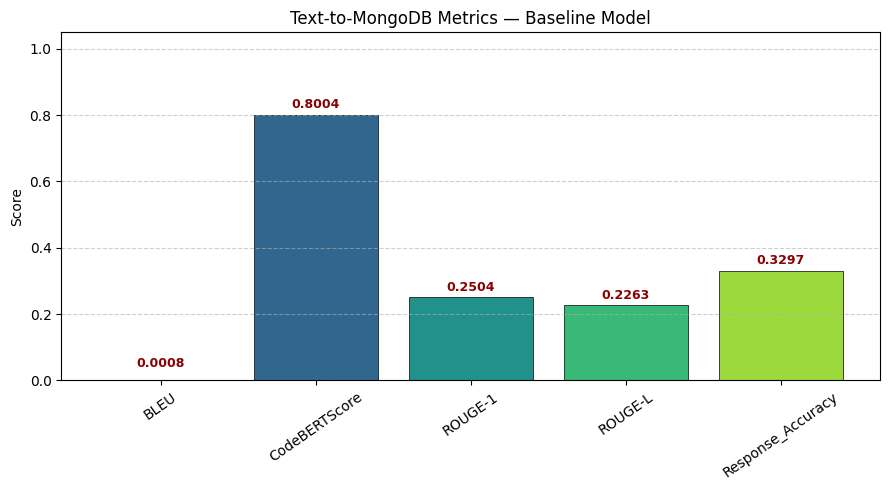

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

metric_names = list(mongo_metrics_baseline.keys())
metric_values = list(mongo_metrics_baseline.values())
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(metric_names)))

# Plot the bars
ax.bar(metric_names, metric_values, color=colors, edgecolor='black', linewidth=0.5)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Text-to-MongoDB Metrics — Baseline Model")
ax.tick_params(axis="x", rotation=35)
ax.grid(axis="y", linestyle="--", alpha=0.6)

for i, v in enumerate(metric_values):
    label_y = max(v + 0.02, 0.04) 
    
    ax.text(i, label_y, f"{v:.4f}", ha="center", fontsize=9, fontweight='bold', color="darkred")

plt.tight_layout()
Path("src/plots").mkdir(parents=True, exist_ok=True)
plt.savefig("src/plots/text_to_mongo_baseline_metrics.png", bbox_inches="tight")
plt.show()

## Consolidated Baseline Model Results Summary

In [9]:
combined_results_baseline = {
    "Text_to_MongoDB": mongo_metrics_baseline,
}

visualizer = ResultVisualizer(output_dir=config.outputs.plots_dir if hasattr(config, "outputs") else "src/plots")
visualizer.plot_comparison(
    combined_results_baseline,
    save_name="baseline_text_to_mongo.png",
    bertscore_model_label=bertscore_model_resolved,
)

summary_rows = []
for task, metrics in combined_results_baseline.items():
    for metric, value in metrics.items():
        summary_rows.append({"Task": task, "Metric": metric, "Score": value})
summary_rows.append({"Task": "Text_to_MongoDB", "Metric": "Avg_Latency_ms", "Score": avg_latency_ms})

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

output_path = Path("output/generated") / "baseline_model_results.json"
output_path.parent.mkdir(parents=True, exist_ok=True)
with open(output_path, "w", encoding="utf-8") as f:
    json.dump({**combined_results_baseline, "Avg_Latency_ms": avg_latency_ms, "n_samples": len(eval_samples)}, f, indent=2)

print(f"\n✅ Baseline Model results saved to: {output_path}")

2026-08-27 22:22:59,153 - src.evaluation.visualization - INFO - ✅ Saved comparison plot to output/plots/baseline_text_to_mongo.png


,Task,Metric,Score
0,Text_to_MongoDB,BLEU,0.0008
1,Text_to_MongoDB,CodeBERTScore,0.8004
2,Text_to_MongoDB,ROUGE-1,0.2504
3,Text_to_MongoDB,ROUGE-L,0.2263
4,Text_to_MongoDB,Response_Accuracy,0.3297
5,Text_to_MongoDB,Avg_Latency_ms,38890.2800



✅ Baseline Model results saved to: output/generated/baseline_model_results.json
